# Curriculum x Reg Ablation 对比

对比 4 种组合:
1. **baseline** - Curriculum OFF, Reg OFF
2. **curriculum_only** - Curriculum ON, Reg OFF
3. **reg_only** - Curriculum OFF, Reg ON
4. **curriculum_reg** - Curriculum ON, Reg ON

In [24]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# ============================================================================
# 配置区
# ============================================================================

# 4个实验文件路径
ablation_dir = '/home/sunj11/Documents/curriculum_sparse_reg/results'

experiments = {
    'baseline': f'{ablation_dir}/results_baseline.pkl',
    'curriculum_only': f'{ablation_dir}/results_curriculum_only.pkl',
    'reg_only': f'{ablation_dir}/results_reg_only.pkl',
    'curriculum_reg': f'{ablation_dir}/results_curriculum_reg.pkl',
}

# 通用配置
show_bias = True
top_n = 30
figsize_single = (18, 50)

In [52]:
# ============================================================================
# 核心函数
# ============================================================================

def load_results(path):
    """加载pickle文件"""
    with open(path, 'rb') as f:
        return pickle.load(f)

def extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary=None):
    """提取Top神经元的数据 (优化版)"""
    result = results[0]
    similarities_history = result.get('training_history', {}).get('similarities', [])
    
    if not similarities_history:
        print("Error: No training history found.")
        return None
    
    # 获取基本信息
    first_entry = similarities_history[0]
    sim_test = first_entry.get('similarities', {}).get(rank_by)
    if sim_test is None:
        print(f"Error: {rank_by} not found in similarities")
        return None
    
    num_neurons = sim_test.shape[0]
    
    # 预分配数组
    iterations = []
    all_sims_rank = {i: [] for i in range(num_neurons)}
    all_sims_primary = {i: [] for i in range(num_neurons)}
    all_sims_secondary = {i: [] for i in range(num_neurons)}
    all_sims_tertiary = {i: [] for i in range(num_neurons)} if plot_tertiary else {}
    all_bias_values = {i: [] for i in range(num_neurons)} if show_bias else {}
    
    # 一次遍历提取所有数据
    for entry in similarities_history:
        iteration = entry.get('iteration', entry.get('epoch', len(iterations) + 1))
        iterations.append(iteration)
        
        # 提取 similarities (批量处理)
        sims_dict = entry.get('similarities', {})
        
        for key, storage in [(rank_by, all_sims_rank), 
                            (plot_primary, all_sims_primary), 
                            (plot_secondary, all_sims_secondary)]:
            sim = sims_dict.get(key)
            if sim is not None:
                sim_np = sim.cpu().numpy()
                for i in range(num_neurons):
                    storage[i].append(sim_np[i])
        
        # plot_tertiary
        if plot_tertiary:
            sim = sims_dict.get(plot_tertiary)
            if sim is not None:
                sim_np = sim.cpu().numpy()
                for i in range(num_neurons):
                    all_sims_tertiary[i].append(sim_np[i])
        
        # 提取 bias (保持与 iterations 同步)
        if show_bias:
            b_hidden = entry.get('model_state', {}).get('neurons', {}).get('b_hidden')
            if b_hidden is not None:
                b_hidden_np = b_hidden.cpu().numpy()
                for i in range(num_neurons):
                    all_bias_values[i].append(b_hidden_np[i])
            else:
                # 如果没有 bias 数据，用上一个值或 0 填充
                for i in range(num_neurons):
                    if all_bias_values[i]:
                        all_bias_values[i].append(all_bias_values[i][-1])
                    else:
                        all_bias_values[i].append(0.0)
    
    # 计算最终排名
    final_max_sims_abs = {}
    for i in range(num_neurons):
        if all_sims_rank[i]:
            final_sims = all_sims_rank[i][-1]
            final_max_sims_abs[i] = np.max(np.abs(final_sims))
        else:
            final_max_sims_abs[i] = 0
    
    sorted_neurons = sorted(final_max_sims_abs.items(), key=lambda x: x[1], reverse=True)
    
    return {
        'iterations': iterations,
        'biases': all_bias_values,
        'sims_rank': all_sims_rank,
        'sims_primary': all_sims_primary,
        'sims_secondary': all_sims_secondary,
        'sims_tertiary': all_sims_tertiary,
        'sorted_neurons': sorted_neurons,
        'num_neurons': num_neurons
    }


def plot_comparison(data, rank_by, plot_primary, plot_secondary, show_bias, top_n, figsize, title_prefix='', plot_tertiary=None):
    """绘制Top N神经元的子图"""
    iterations = data['iterations']
    biases = data['biases']
    sims_primary = data['sims_primary']
    sims_secondary = data['sims_secondary']
    sims_tertiary = data.get('sims_tertiary', {})
    sorted_neurons = data['sorted_neurons']
    
    n_rows = (top_n + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten() if top_n > 1 else [axes]
    
    fig.suptitle(f'{title_prefix} | Rank by: {rank_by}', fontsize=14, fontweight='bold', y=1.02)
    
    for i, (neuron_idx, final_abs_sim) in enumerate(sorted_neurons[:top_n]):
        ax = axes[i]
        
        # plot_primary: 蓝色粗线 (max)
        max_sims_primary_signed = []
        for t in range(len(iterations)):
            sims = sims_primary[neuron_idx][t]
            max_idx = np.argmax(np.abs(sims))
            max_sims_primary_signed.append(sims[max_idx])
        
        ax.plot(iterations, max_sims_primary_signed, 
               color='blue', linewidth=2.5, alpha=0.8, 
               label=f'max(<wi, {plot_primary[2:]}j>)', linestyle='-')
        
        # plot_secondary: 红色细线 (各 feature) - M2
        num_features = len(sims_secondary[neuron_idx][0])
        for j in range(num_features):
            feature_curve = [sims_secondary[neuron_idx][t][j] for t in range(len(iterations))]
            if j == 0:
                ax.plot(iterations, feature_curve, 
                       color='red', linewidth=0.8, alpha=0.3, 
                       label=f'<wi, {plot_secondary[2:]}j>', linestyle='-')
            else:
                ax.plot(iterations, feature_curve, 
                       color='red', linewidth=0.8, alpha=0.3, linestyle='-')
        
        # plot_tertiary: 青色细线 (各 feature) - M1
        if plot_tertiary and sims_tertiary and neuron_idx in sims_tertiary and sims_tertiary[neuron_idx]:
            num_features_t = len(sims_tertiary[neuron_idx][0])
            for j in range(num_features_t):
                feature_curve = [sims_tertiary[neuron_idx][t][j] for t in range(len(iterations))]
                if j == 0:
                    ax.plot(iterations, feature_curve, 
                           color='cyan', linewidth=0.8, alpha=0.3, 
                           label=f'<wi, {plot_tertiary[2:]}j>', linestyle='-')
                else:
                    ax.plot(iterations, feature_curve, 
                           color='cyan', linewidth=0.8, alpha=0.3, linestyle='-')
        
        # Bias: 确保长度匹配
        if show_bias and biases and neuron_idx in biases and biases[neuron_idx]:
            bias_values = biases[neuron_idx]
            # 确保 bias 长度与 iterations 匹配
            if len(bias_values) == len(iterations):
                ax.plot(iterations, bias_values, 
                       color='green', linewidth=2.5, alpha=0.9, 
                       label='Bias', linestyle='--')
        
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        
        final_bias = biases[neuron_idx][-1] if (show_bias and biases and biases[neuron_idx]) else 0
        title = f'Neuron {neuron_idx} (Rank {i+1})\n'
        title += f'max|{rank_by}|={final_abs_sim:.3f}'
        if show_bias:
            title += f', bias={final_bias:.3f}'
        
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Iteration', fontsize=9)
        ax.set_ylabel('Similarity / Bias', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.legend(fontsize=7, loc='best', framealpha=0.9)
        
        y_min, y_max = ax.get_ylim()
        y_range = max(abs(y_min), abs(y_max))
        ax.set_ylim(-y_range * 1.1, y_range * 1.1)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    return fig, axes


def print_ranking_table(data, rank_by, top_n, show_bias, name=''):
    """打印排名表格"""
    sorted_neurons = data['sorted_neurons']
    biases = data['biases']
    sims_rank = data['sims_rank']
    
    print(f"\n{'='*60}")
    print(f"{name} | Top {top_n} by max|{rank_by}|")
    print(f"{'='*60}")
    
    for rank, (neuron_idx, sim_val_abs) in enumerate(sorted_neurons[:top_n], 1):
        final_sims = sims_rank[neuron_idx][-1]
        max_idx = np.argmax(np.abs(final_sims))
        signed_max = final_sims[max_idx]
        sign = '+' if signed_max >= 0 else '-'
        
        if show_bias and biases and biases[neuron_idx]:
            bias_val = biases[neuron_idx][-1]
            print(f"Rank {rank:2d}: Neuron {neuron_idx:3d} | sim={sim_val_abs:.4f} ({sign}) | bias={bias_val:.4f}")
        else:
            print(f"Rank {rank:2d}: Neuron {neuron_idx:3d} | sim={sim_val_abs:.4f} ({sign})")
    print()

In [53]:
# ============================================================================
# 加载 4 个实验数据
# ============================================================================

print("Loading ablation experiment data...")
all_results = {}
for name, path in experiments.items():
    try:
        all_results[name] = load_results(path)
        print(f"  Loaded: {name}")
    except FileNotFoundError:
        print(f"  Not found: {name} ({path})")
print("Done!")

Loading ablation experiment data...
  Not found: baseline (/home/sunj11/Documents/curriculum_sparse_reg/results/results_baseline.pkl)
  Loaded: curriculum_only
  Not found: reg_only (/home/sunj11/Documents/curriculum_sparse_reg/results/results_reg_only.pkl)
  Loaded: curriculum_reg
Done!


---
## Summary: 4 实验对比

In [54]:
# 打印 4 个实验的关键指标对比
print("\n" + "="*80)
print("ABLATION SUMMARY: Curriculum x Reg (Group L1)")
print("="*80)
print(f"{'Experiment':<25} {'Curriculum':<12} {'Reg':<12} {'W-M1 max':<12} {'W-M2 max':<12}")
print("-"*80)

config_map = {
    'baseline': ('OFF', 'OFF'),
    'curriculum_only': ('ON', 'OFF'),
    'reg_only': ('OFF', 'ON'),
    'curriculum_reg': ('ON', 'ON'),
}

for name, results in all_results.items():
    result = results[0]
    metrics = result.get('metrics', {})
    w_m1_max = metrics.get('W_M1_max', 0)
    w_m2_max = metrics.get('W_M2_max', 0)
    curr, reg = config_map.get(name, ('?', '?'))
    print(f"{name:<25} {curr:<12} {reg:<12} {w_m1_max:<12.4f} {w_m2_max:<12.4f}")

print("="*80)


ABLATION SUMMARY: Curriculum x Reg (Group L1)
Experiment                Curriculum   Reg          W-M1 max     W-M2 max    
--------------------------------------------------------------------------------
curriculum_only           ON           OFF          1.0005       1.2504      
curriculum_reg            ON           ON           1.1866       0.7094      


---
## Rank by W_M2 (同时显示 W_M1)

In [55]:
rank_by = 'W_M2'
plot_primary = 'W_M2'
plot_secondary = 'W_M2'
plot_tertiary = 'W_M1' 

# 提取并打印排名表
all_data_w_m2 = {}
for name, results in all_results.items():
    data = extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    all_data_w_m2[name] = data
    if data:
        print_ranking_table(data, rank_by, top_n, show_bias, name)


curriculum_only | Top 30 by max|W_M2|
Rank  1: Neuron  44 | sim=1.2504 (+) | bias=-0.3297
Rank  2: Neuron  20 | sim=1.1856 (+) | bias=0.0520
Rank  3: Neuron  97 | sim=1.1230 (+) | bias=0.0325
Rank  4: Neuron  79 | sim=1.0864 (+) | bias=-0.2125
Rank  5: Neuron  49 | sim=0.8281 (+) | bias=0.0665
Rank  6: Neuron  72 | sim=0.7647 (+) | bias=0.0632
Rank  7: Neuron  85 | sim=0.3856 (+) | bias=-0.9204
Rank  8: Neuron  59 | sim=0.3691 (+) | bias=-1.0306
Rank  9: Neuron  32 | sim=0.2540 (+) | bias=-1.2306
Rank 10: Neuron  11 | sim=0.2354 (+) | bias=-0.9874
Rank 11: Neuron   6 | sim=0.2100 (+) | bias=-1.0362
Rank 12: Neuron   8 | sim=0.2096 (-) | bias=-1.1543
Rank 13: Neuron  25 | sim=0.1890 (-) | bias=-1.2036
Rank 14: Neuron  42 | sim=0.1789 (-) | bias=-0.9935
Rank 15: Neuron  50 | sim=0.1776 (-) | bias=-1.1356
Rank 16: Neuron  98 | sim=0.1752 (+) | bias=-1.0810
Rank 17: Neuron  13 | sim=0.1655 (+) | bias=-1.2629
Rank 18: Neuron  78 | sim=0.1636 (+) | bias=-1.3446
Rank 19: Neuron  19 | sim=0.1

In [56]:
# baseline | W_M2 + W_M1
if 'baseline' in all_data_w_m2 and all_data_w_m2['baseline']:
    fig, _ = plot_comparison(all_data_w_m2['baseline'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='baseline (C:OFF, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

In [57]:
# reg_only | W_M2 + W_M1
if 'reg_only' in all_data_w_m2 and all_data_w_m2['reg_only']:
    fig, _ = plot_comparison(all_data_w_m2['reg_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='reg_only (C:OFF, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

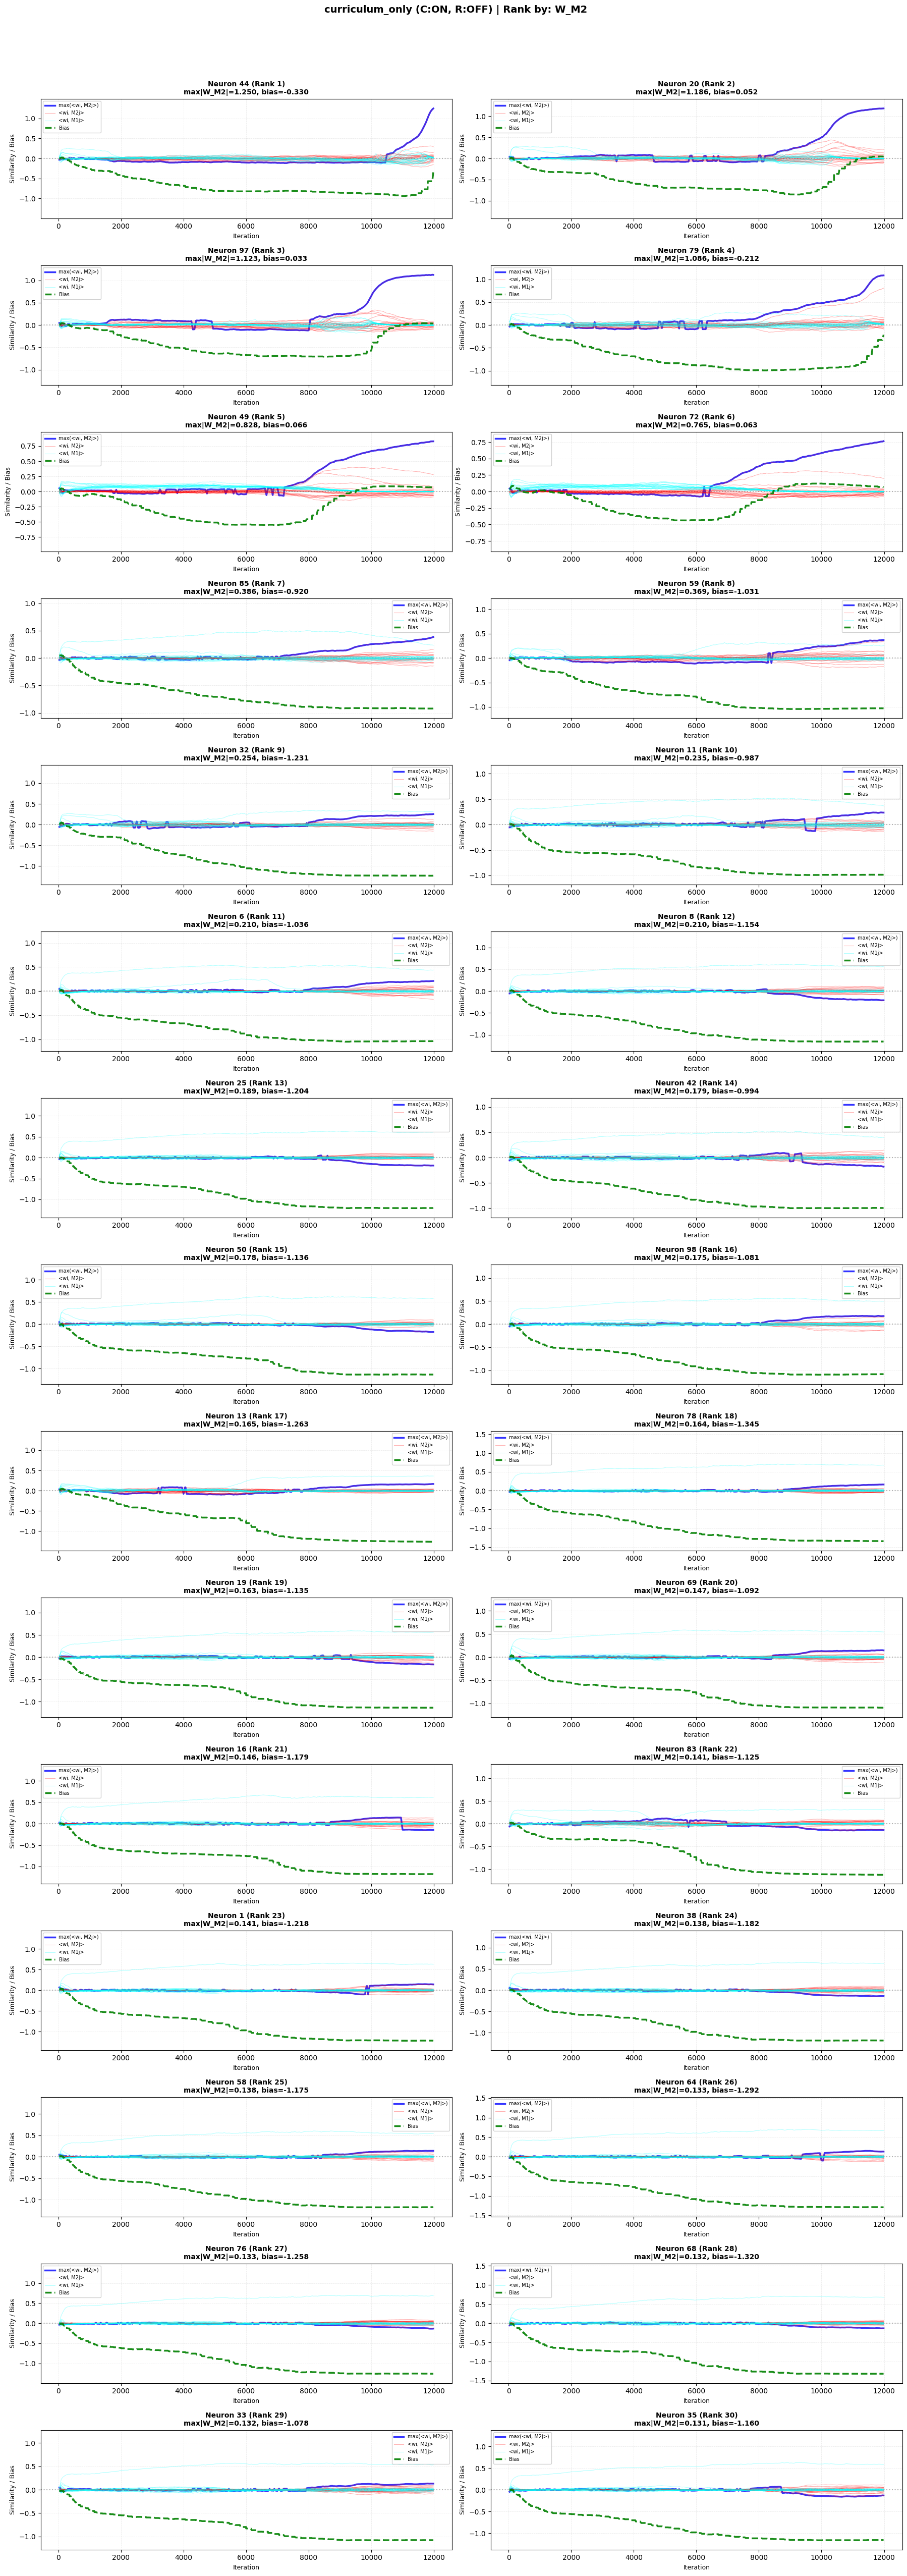

In [58]:
# curriculum_only | W_M2 + W_M1
if 'curriculum_only' in all_data_w_m2 and all_data_w_m2['curriculum_only']:
    fig, _ = plot_comparison(all_data_w_m2['curriculum_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_only (C:ON, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

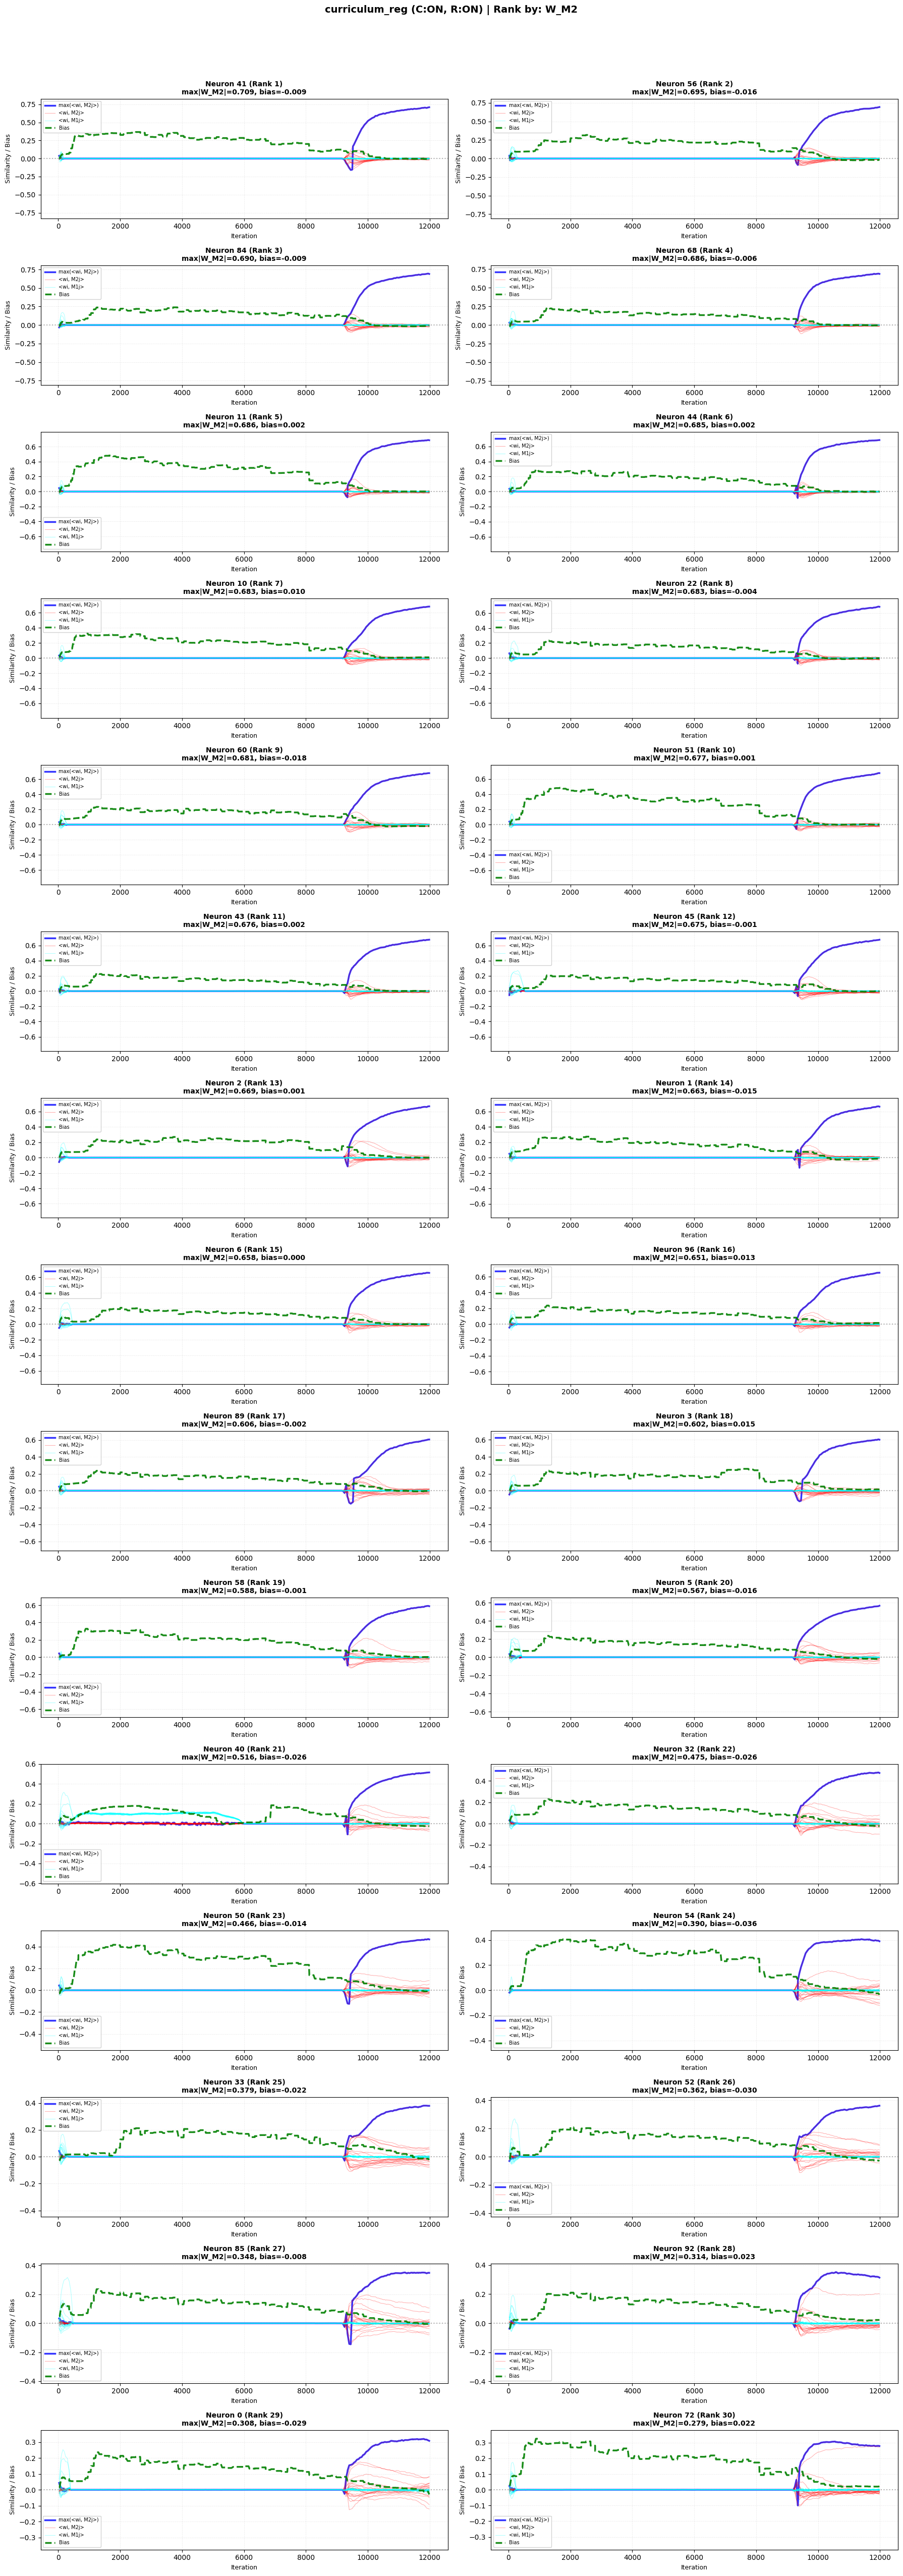

In [59]:
# curriculum_reg | W_M2 + W_M1
if 'curriculum_reg' in all_data_w_m2 and all_data_w_m2['curriculum_reg']:
    fig, _ = plot_comparison(all_data_w_m2['curriculum_reg'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_reg (C:ON, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

---
## Rank by W_M1

In [60]:
rank_by = 'W_M1'
plot_primary = 'W_M1'
plot_secondary = 'W_M1'
plot_tertiary = 'W_M2'

# 提取并打印排名表
all_data_w_m1 = {}
for name, results in all_results.items():
    data = extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    all_data_w_m1[name] = data
    if data:
        print_ranking_table(data, rank_by, top_n, show_bias, name)


curriculum_only | Top 30 by max|W_M1|
Rank  1: Neuron  84 | sim=1.0005 (+) | bias=-1.7527
Rank  2: Neuron  43 | sim=0.8905 (+) | bias=-1.5385
Rank  3: Neuron  61 | sim=0.8895 (+) | bias=-1.5095
Rank  4: Neuron   2 | sim=0.8827 (+) | bias=-1.5885
Rank  5: Neuron  24 | sim=0.8827 (+) | bias=-1.5611
Rank  6: Neuron  80 | sim=0.8779 (+) | bias=-1.5110
Rank  7: Neuron  57 | sim=0.8728 (+) | bias=-1.5025
Rank  8: Neuron  15 | sim=0.8653 (+) | bias=-1.4766
Rank  9: Neuron  96 | sim=0.8648 (+) | bias=-1.4292
Rank 10: Neuron  31 | sim=0.8484 (+) | bias=-1.4569
Rank 11: Neuron  70 | sim=0.8396 (+) | bias=-1.4786
Rank 12: Neuron   5 | sim=0.8223 (+) | bias=-1.4768
Rank 13: Neuron  71 | sim=0.8080 (+) | bias=-1.4246
Rank 14: Neuron  18 | sim=0.7618 (+) | bias=-1.3932
Rank 15: Neuron   3 | sim=0.7564 (+) | bias=-1.2862
Rank 16: Neuron  45 | sim=0.7559 (+) | bias=-1.4079
Rank 17: Neuron  22 | sim=0.7541 (+) | bias=-1.3426
Rank 18: Neuron  99 | sim=0.7532 (+) | bias=-1.3613
Rank 19: Neuron  37 | sim

In [61]:
# baseline | W_M1 + W_M2
if 'baseline' in all_data_w_m1 and all_data_w_m1['baseline']:
    fig, _ = plot_comparison(all_data_w_m1['baseline'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='baseline (C:OFF, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

In [62]:
# reg_only | W_M1 + W_M2
if 'reg_only' in all_data_w_m1 and all_data_w_m1['reg_only']:
    fig, _ = plot_comparison(all_data_w_m1['reg_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='reg_only (C:OFF, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

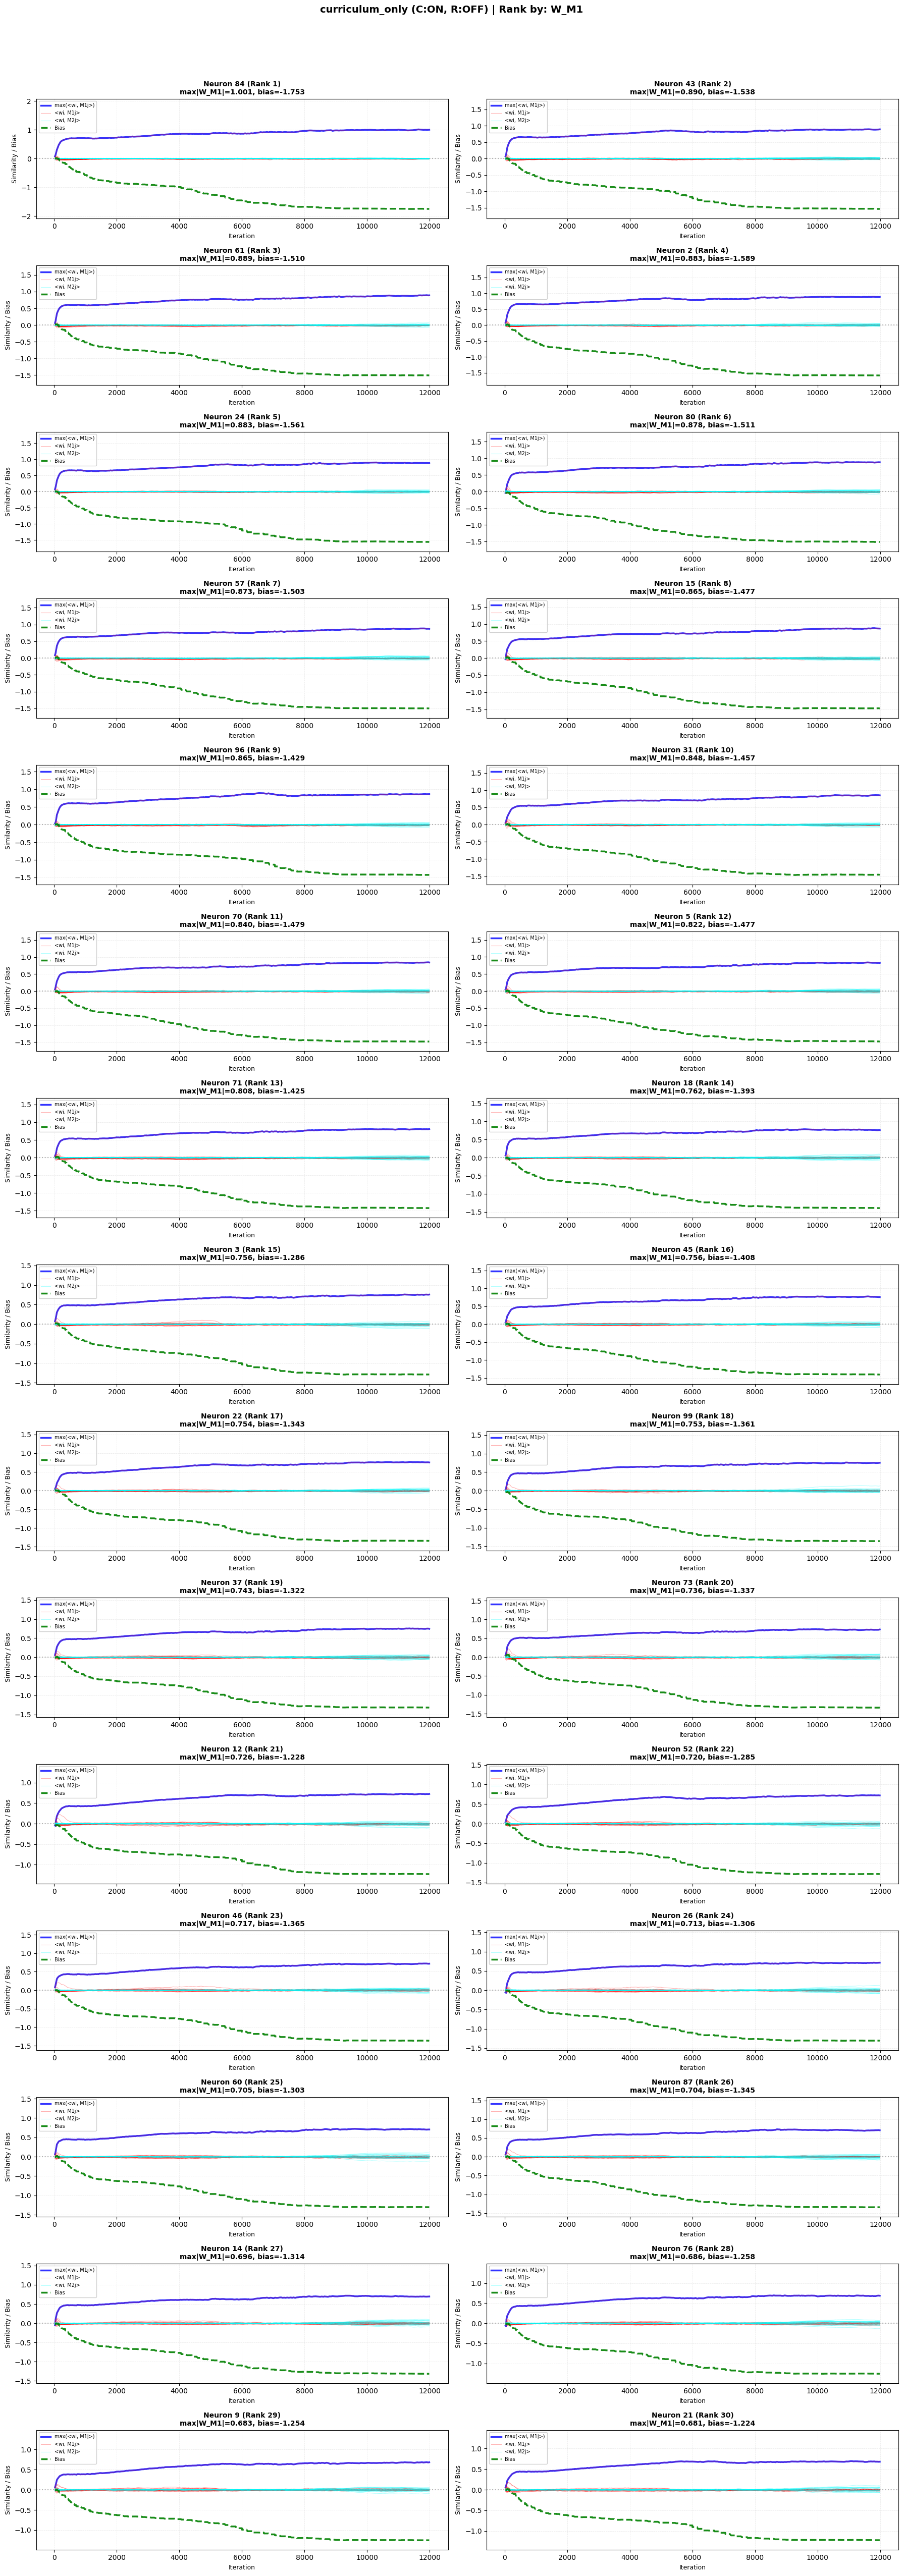

In [63]:
# curriculum_only | W_M1 + W_M2
if 'curriculum_only' in all_data_w_m1 and all_data_w_m1['curriculum_only']:
    fig, _ = plot_comparison(all_data_w_m1['curriculum_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_only (C:ON, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

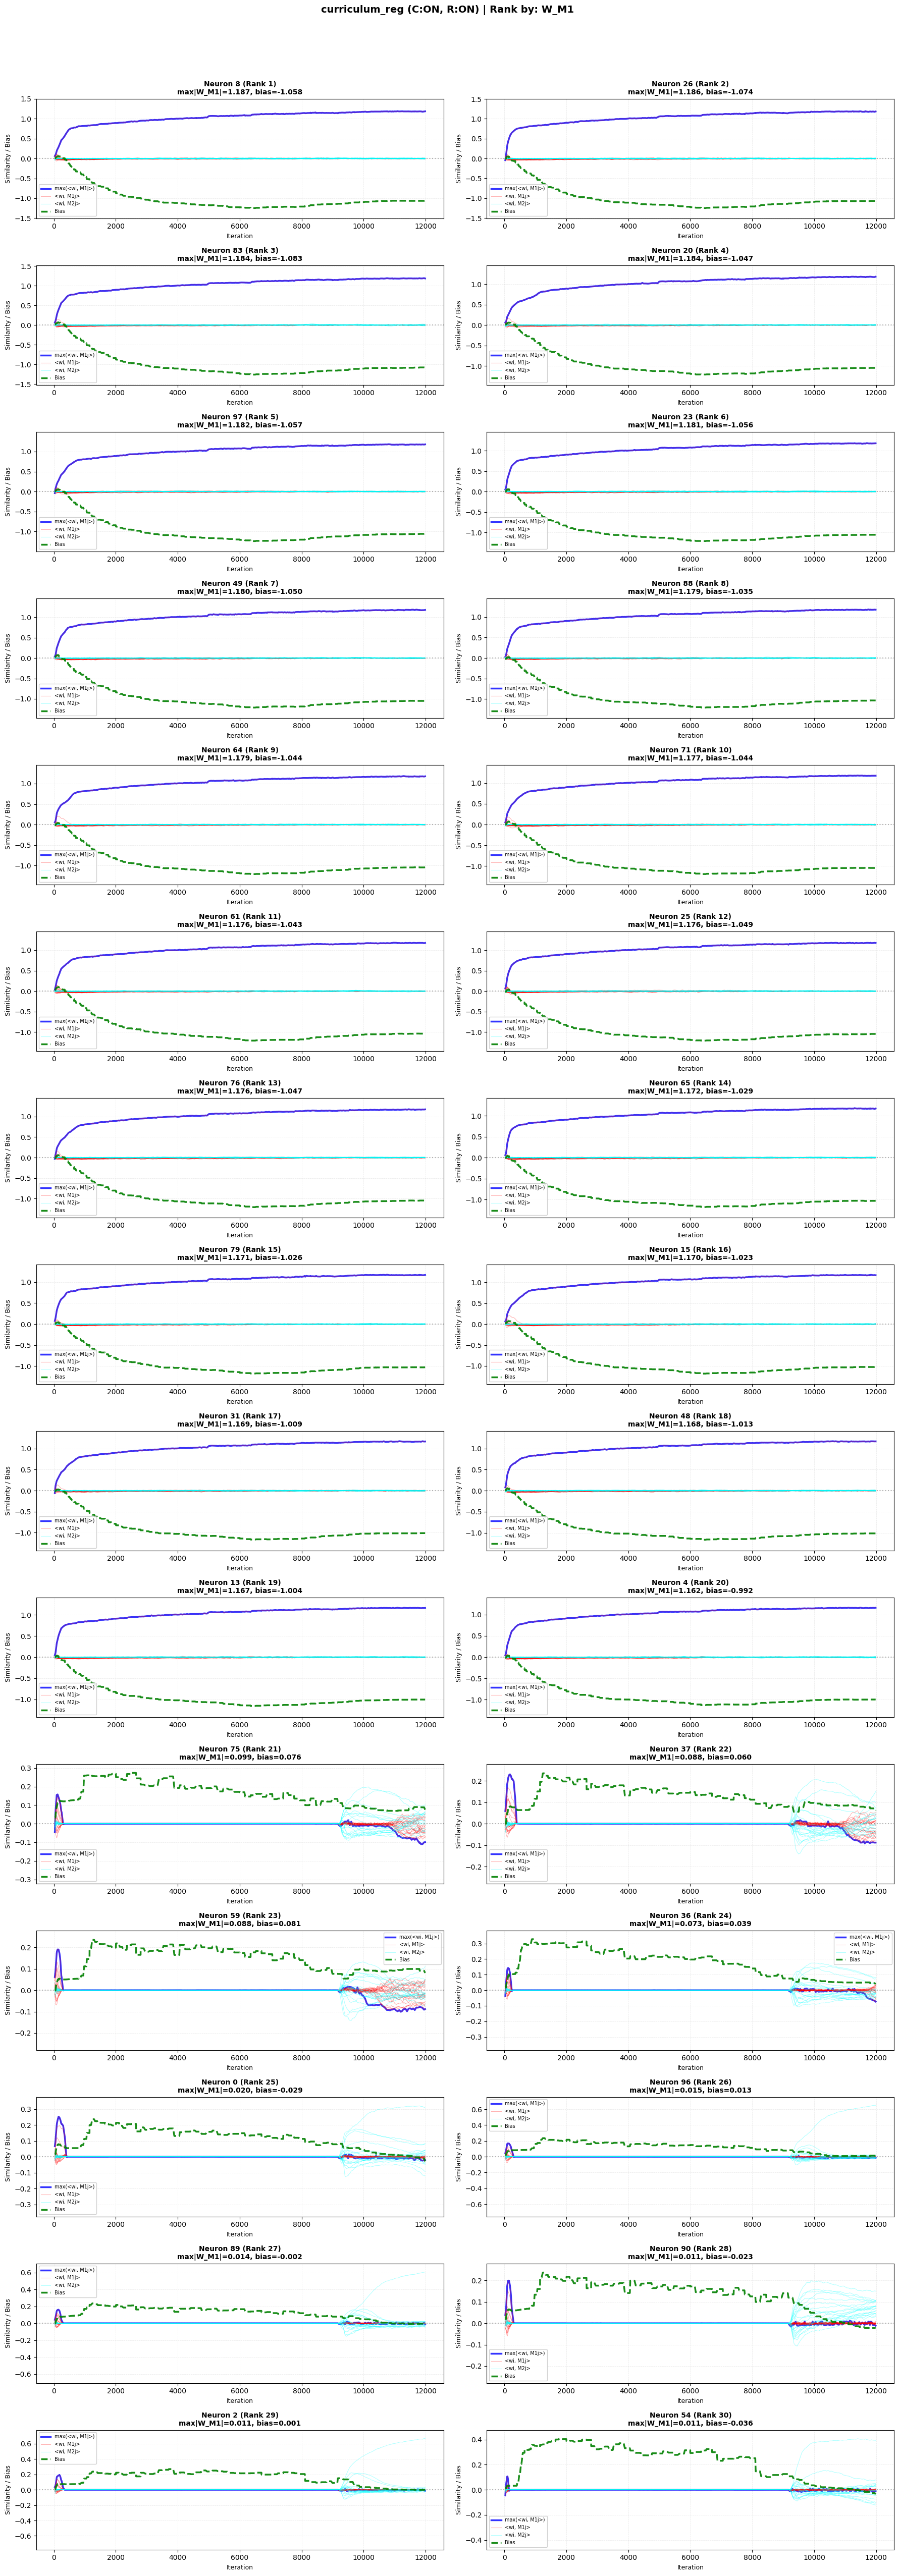

In [64]:
# curriculum_reg | W_M1 + W_M2
if 'curriculum_reg' in all_data_w_m1 and all_data_w_m1['curriculum_reg']:
    fig, _ = plot_comparison(all_data_w_m1['curriculum_reg'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_reg (C:ON, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

---
## Group L1 Regularization 特有分析

In [65]:
# 分析 reg_only 和 curriculum_reg 的稀疏性
print("\n" + "="*80)
print("GROUP L1 REGULARIZATION ANALYSIS")
print("="*80)

for name in ['reg_only', 'curriculum_reg']:
    if name not in all_results:
        print(f"\n{name}: Not loaded")
        continue
        
    result = all_results[name][0]
    
    # 检查是否有 sparsity_history
    sparsity_history = result.get('training_history', {}).get('sparsity_history', [])
    lambda_history = result.get('training_history', {}).get('lambda_history', [])
    
    print(f"\n{name}:")
    print(f"  is_reg: {result.get('is_reg', False)}")
    
    if lambda_history:
        lambda_vals = [f"{h['lambda']:.4f}" for h in lambda_history]
        print(f"  Lambda schedule: {lambda_vals}")
    
    if sparsity_history:
        final_sparsity = sparsity_history[-1]
        print(f"  Final active neurons: {final_sparsity.get('active_neurons', '?')}/{final_sparsity.get('total_neurons', '?')}")
        print(f"  Final sparsity: {final_sparsity.get('sparsity', 0):.1%}")
    else:
        print(f"  No sparsity history found")

print("\n" + "="*80)


GROUP L1 REGULARIZATION ANALYSIS

reg_only: Not loaded

curriculum_reg:
  is_reg: True
  Lambda schedule: ['0.0010', '0.0009', '0.0008', '0.0007', '0.0006', '0.0004', '0.0003', '0.0002', '0.0001', '0.0000']
  Final active neurons: 69/100
  Final sparsity: 31.0%



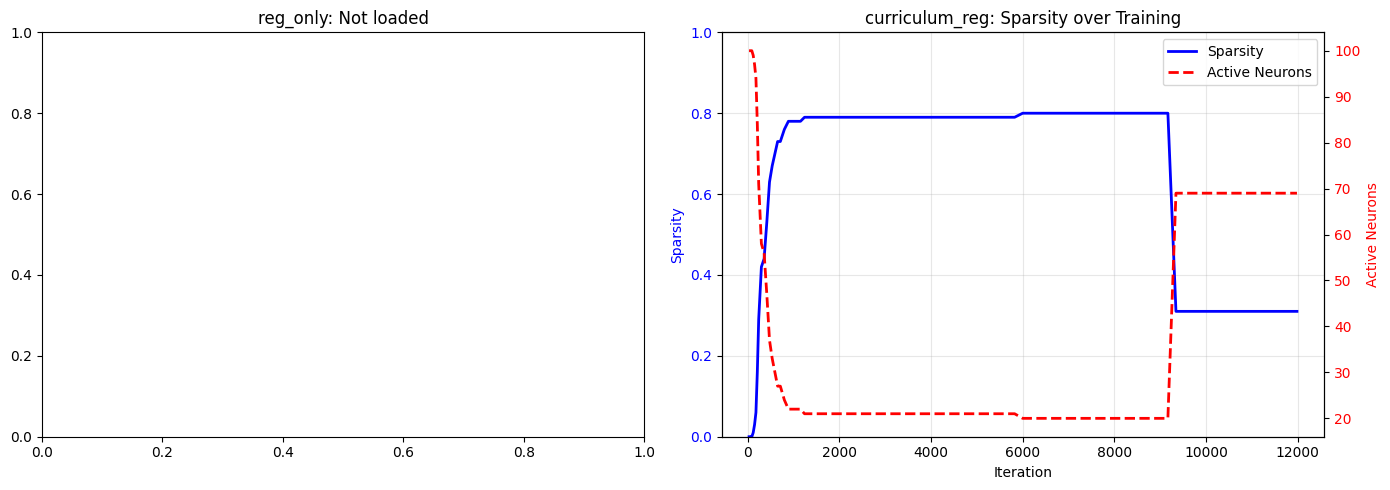

In [66]:
# 绘制稀疏度随训练变化曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, name in enumerate(['reg_only', 'curriculum_reg']):
    ax = axes[idx]
    
    if name not in all_results:
        ax.set_title(f'{name}: Not loaded')
        continue
    
    result = all_results[name][0]
    sparsity_history = result.get('training_history', {}).get('sparsity_history', [])
    
    if not sparsity_history:
        ax.set_title(f'{name}: No sparsity history')
        continue
    
    iterations = [h.get('iteration', i) for i, h in enumerate(sparsity_history)]
    sparsities = [h.get('sparsity', 0) for h in sparsity_history]
    active_neurons = [h.get('active_neurons', 0) for h in sparsity_history]
    
    ax.plot(iterations, sparsities, 'b-', linewidth=2, label='Sparsity')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Sparsity', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_ylim(0, 1)
    
    ax2 = ax.twinx()
    ax2.plot(iterations, active_neurons, 'r--', linewidth=2, label='Active Neurons')
    ax2.set_ylabel('Active Neurons', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_title(f'{name}: Sparsity over Training')
    ax.grid(True, alpha=0.3)
    
    # 合并图例
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()